In [1]:
import os
from datetime import datetime

In [2]:
import arcgis
from arcgis.gis import GIS

gis = GIS("https://pythonapi.playground.esri.com/portal", "arcgis_python", "amazing_arcgis_123")
gis

GIS @ https://pythonapi.playground.esri.com/portal version:7.1

In [3]:
arcgis.env.verbose=True

In [4]:
clip1_m_4712101_nw_10_1_20150928=gis.content.search("clip1_m_4712101_nw_10_1_20150928")[0].layers[0]
clip1_m_4712101_nw_10_1_20150928.url

'https://pythonapi.playground.esri.com/server/rest/services/clip1_m_4712101_nw_10_1_20150928/ImageServer'

Segment Basic Case

Submitted.
Executing...
Segment GP Job: j29ec11ebee3147d284fd07055d837cc7 finished successfully.


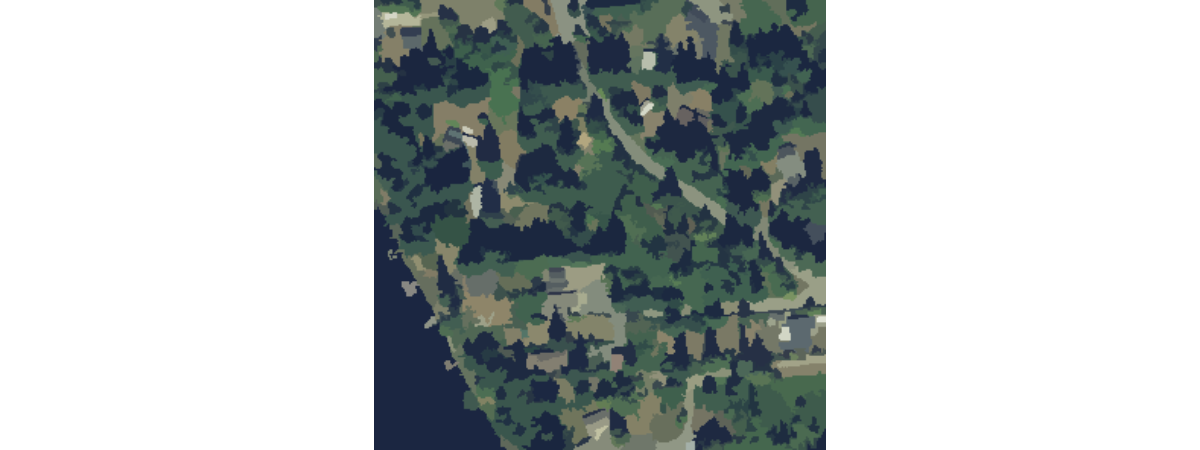

In [5]:
segment_1 = arcgis.raster.analytics.segment(input_raster=clip1_m_4712101_nw_10_1_20150928,
                                              spectral_detail="15.5",
                                              spatial_detail="15",
                                              minimum_segment_size_in_pixels=20,
                                              band_indexes=[0, 1, 2],
                                              remove_tiling_artifacts=False,
                                              output_name="segment" + str(datetime.now().strftime('%Y%m%d%H%M%S')),
                                              gis=gis)
segment_1.layers[0]

In [6]:
aoi={"xmin": 576706.790671783,"ymin": 5310447.00119336,"xmax": 576827.68062284,"ymax": 5310532.35527976,"spatialReference": {"wkid": 26910,"latestWkid": 26910}}

Segment with extent set in context param

Segment GP Job: j63744c47ce914e2eb93c6e13d115d6af finished successfully.


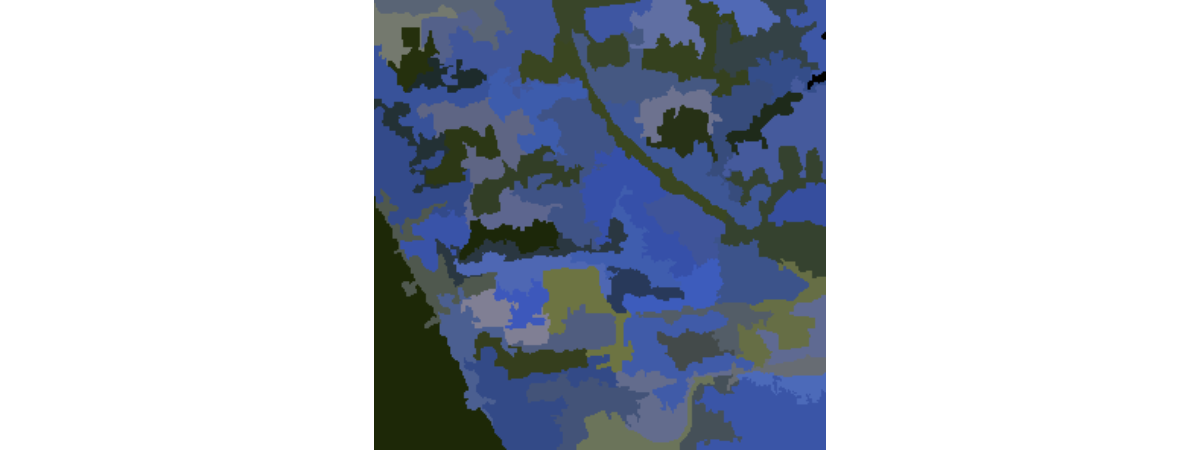

In [7]:
segment_2 = arcgis.raster.analytics.segment(input_raster=clip1_m_4712101_nw_10_1_20150928,
                                            spectral_detail="15.5",
                                            spatial_detail="15",
                                            minimum_segment_size_in_pixels=512,
                                            band_indexes=[0, 1, 3],
                                            remove_tiling_artifacts=False,
                                            future=True,
                                            context={"extent":aoi},
                                            output_name="segment" + str(datetime.now().strftime('%Y%m%d%H%M%S')),
                                            gis=gis)
segment_2.result().layers[0]

Copy raster with environment variable analysis_extent set

Submitted.
Executing...
Segment GP Job: ja1e129dac9424c40b7e9787eed530ffe finished successfully.


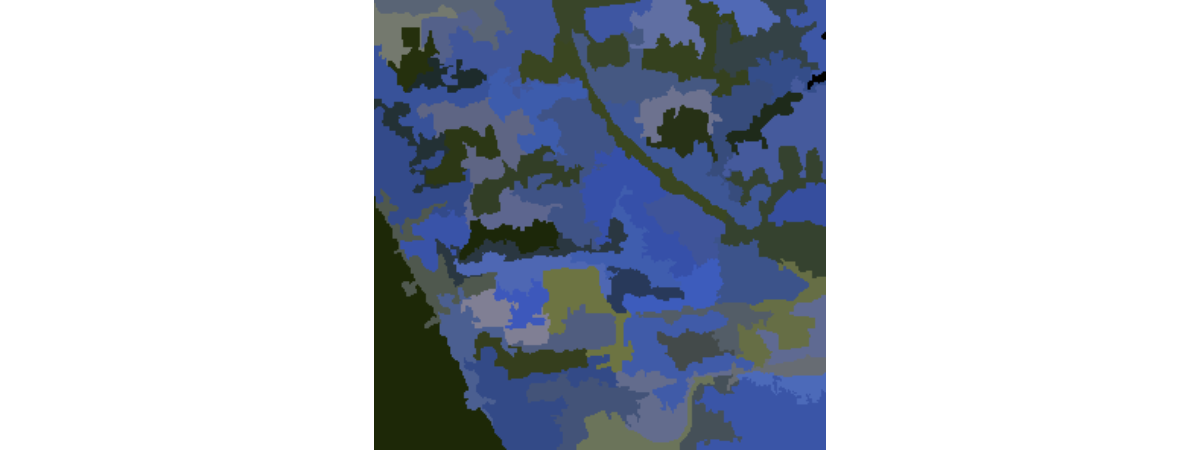

In [8]:
arcgis.env.analysis_extent=aoi
segment_3 = arcgis.raster.analytics.segment(input_raster=clip1_m_4712101_nw_10_1_20150928,
                                            spectral_detail="15.5",
                                            spatial_detail="15",
                                            minimum_segment_size_in_pixels=512,
                                            band_indexes=[0,1,3],
                                            remove_tiling_artifacts=False,
                                            future=True,
                                            output_name="segment" + str(datetime.now().strftime('%Y%m%d%H%M%S')),
                                            gis=gis)
segment_3.result().layers[0]

In [9]:
arcgis.env.analysis_extent=None

<h4> Clean Up

In [10]:
segment_1.delete()

True

In [11]:
segment_2.result().delete()

True

In [12]:
segment_3.result().delete()

True